# Model Training

This notebook holds a proof of concept of how the CreditKarma Scorer model would be trained using the gold table. CreditKarma Scorer is a binary classification logistic regression model that outputs the **probability of a customer defaulting their loan**. Loaning decisions are made by setting a threshold probability based on **F2-score**, as we want to be conservative in giving out loans and prioritize low-risk individuals (i.e. minimize false negatives from CreditKarma Scorer, which rates a high risk individual as low risk).

In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyspark
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

import pickle


In [18]:
from pyspark.sql import SparkSession

# Start a Spark session
spark = SparkSession.builder.appName("InspectParquet").getOrCreate()

# Path to your Parquet file or directory
parquet_path = "datamart/gold/label_Store/2023_01_01.parquet"

# Read the Parquet file
df = spark.read.parquet(parquet_path)

# Show first few rows
df.show(5)

# Print schema
df.printSchema()

+-------+-----------+-----+---------+-------------+
|loan_id|customer_id|label|label_def|snapshot_date|
+-------+-----------+-----+---------+-------------+
+-------+-----------+-----+---------+-------------+

root
 |-- loan_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: string (nullable = true)



**Import data from gold table**

In [3]:
spark = pyspark.sql.SparkSession.builder \
    .appName("model-training") \
    .master("local[*]") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/27 10:01:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
def read_gold_table(table, gold_db, spark):
    """
    Helper function to read all partitions of a gold table
    """
    folder_path = os.path.join(gold_db, table)
    files_list = [os.path.join(folder_path, os.path.basename(f)) for f in glob.glob(os.path.join(folder_path, '*'))]
    df = spark.read.option("header", "true").parquet(*files_list)
    return df


In [5]:
X_spark = read_gold_table('feature_store', 'datamart/gold', spark)
y_spark = read_gold_table('label_store', 'datamart/gold', spark)

In [6]:
X_df = X_spark.toPandas().sort_values(by='customer_id')
y_df = y_spark.toPandas().sort_values(by='customer_id')

25/06/27 10:04:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

**Set train test split**

In [7]:
model_train_date_str = "2024-09-02" # pretend we're training the model at this time
train_test_period_months = 12
oot_period_months = 2
train_test_ratio = 0.2

config = {}
config["model_train_date_str"] = model_train_date_str
config["train_test_period_months"] = train_test_period_months
config["oot_period_months"] =  oot_period_months
config["model_train_date"] =  datetime.strptime(model_train_date_str, "%Y-%m-%d").date()
config["oot_end_date"] =  config['model_train_date'] - timedelta(days = 1)
config["oot_start_date"] =  config['model_train_date'] - relativedelta(months = oot_period_months)
config["train_test_end_date"] =  config["oot_start_date"] - timedelta(days = 1)
config["train_test_start_date"] =  config["oot_start_date"] - relativedelta(months = train_test_period_months)
config["train_test_ratio"] = train_test_ratio 

config

{'model_train_date_str': '2024-09-02',
 'train_test_period_months': 12,
 'oot_period_months': 2,
 'model_train_date': datetime.date(2024, 9, 2),
 'oot_end_date': datetime.date(2024, 9, 1),
 'oot_start_date': datetime.date(2024, 7, 2),
 'train_test_end_date': datetime.date(2024, 7, 1),
 'train_test_start_date': datetime.date(2023, 7, 2),
 'train_test_ratio': 0.2}

Split OOT

In [8]:
# Consider data from model training date
y_model_df = y_df[(y_df['snapshot_date'] >= config['train_test_start_date']) & (y_df['snapshot_date'] <= config['model_train_date'])]
X_model_df = X_df[np.isin(X_df['customer_id'], y_model_df['customer_id'].unique())]

# Create OOT split
y_oot = y_model_df[(y_model_df['snapshot_date'] >= config['oot_start_date']) & (y_model_df['snapshot_date'] <= config['oot_end_date'])]
X_oot = X_model_df[np.isin(X_model_df['customer_id'], y_oot['customer_id'].unique())]

# Everything else goes into train-test
y_traintest = y_model_df[y_model_df['snapshot_date'] <= config['train_test_end_date']]
X_traintest = X_model_df[np.isin(X_model_df['customer_id'], y_traintest['customer_id'].unique())]

Split train-test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_traintest, y_traintest, 
                                                    test_size=config['train_test_ratio'], 
                                                    random_state=611, 
                                                    shuffle=True, 
                                                    stratify=y_traintest['label'])

In [10]:
# Transform data into numpy arrays
X_train_arr = X_train.drop(columns=['customer_id', 'snapshot_date']).values
X_test_arr = X_test.drop(columns=['customer_id', 'snapshot_date']).values
X_oot_arr = X_oot.drop(columns=['customer_id', 'snapshot_date']).values

y_train_arr = y_train['label'].values
y_test_arr = y_test['label'].values
y_oot_arr = y_oot['label'].values

Normalize data

In [11]:
scaler = StandardScaler()
X_train_arr = scaler.fit_transform(X_train_arr)
X_test_arr = scaler.transform(X_test_arr)
X_oot_arr = scaler.transform(X_oot_arr)

**Train XGBoost**

In [14]:
# Validate bad rates are similar
train_bad_rate = y_train["label"].mean()
test_bad_rate = y_test["label"].mean()
oot_bad_rate = y_oot["label"].mean()

if abs(train_bad_rate - test_bad_rate) > 0.05 or abs(train_bad_rate - oot_bad_rate) > 0.05:
    print("WARNING: Bad rates differ significantly between splits. Consider investigating data distribution.")
else:     
    # Prepare arrays, drop unwanted columns
    X_train_arr = X_train.drop(columns=['customer_id', 'snapshot_date']).values
    X_test_arr = X_test.drop(columns=['customer_id', 'snapshot_date']).values
    X_oot_arr = X_oot.drop(columns=['customer_id', 'snapshot_date']).values

    y_train_arr = y_train['label'].values
    y_test_arr = y_test['label'].values
    y_oot_arr = y_oot['label'].values

    # Scale features
    scaler = StandardScaler()
    X_train_arr = scaler.fit_transform(X_train_arr)
    X_test_arr = scaler.transform(X_test_arr)
    X_oot_arr = scaler.transform(X_oot_arr)

In [30]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5.0),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'use_label_encoder': False,
        'eval_metric': 'auc'
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_arr, y_train_arr,
        eval_set=[(X_test_arr, y_test_arr)],
        verbose=False
    )

    y_pred = model.predict_proba(X_test_arr)[:, 1]
    return roc_auc_score(y_test_arr, y_pred)


In [31]:
# pip install xgboost

In [32]:
import optuna
from xgboost import XGBClassifier

# Run the optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Get best parameters
best_params = study.best_params
print(f"Best ROC AUC: {study.best_value:.4f}")
print(f"Best parameters: {best_params}")

[I 2025-06-27 10:30:20,675] A new study created in memory with name: no-name-898469ae-ebff-4411-b7c3-39fd09c30ac8
/usr/local/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:30:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-06-27 10:30:24,889] Trial 0 finished with value: 0.8532334302020237 and parameters: {'n_estimators': 473, 'max_depth': 7, 'learning_rate': 0.036868383415559175, 'subsample': 0.9815978072132319, 'colsample_bytree': 0.8231890794074648, 'min_child_weight': 8, 'gamma': 0.5703606677887929, 'lambda': 0.36079401647204545, 'alpha': 0.01616527440061839}. Best is trial 0 with value: 0.8532334302020237.
/usr/local/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:30:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-06-27 10:30:26,695] Tria

Best ROC AUC: 0.8579
Best parameters: {'n_estimators': 476, 'max_depth': 6, 'learning_rate': 0.027394776857803324, 'subsample': 0.6134542724053156, 'colsample_bytree': 0.949554128982436, 'min_child_weight': 6, 'gamma': 2.9525677092052467, 'lambda': 9.929149124393032, 'alpha': 0.0012239649327683913}


In [33]:
# Train final model with best parameters
best_model = XGBClassifier(**best_params)
best_model.fit(X_train_arr, y_train_arr)

print(f"Best parameters for XGBoost: {study.best_params}")
print(f"Best cross-validation AUC: {study.best_value:.4f}")

Best parameters for XGBoost: {'n_estimators': 476, 'max_depth': 6, 'learning_rate': 0.027394776857803324, 'subsample': 0.6134542724053156, 'colsample_bytree': 0.949554128982436, 'min_child_weight': 6, 'gamma': 2.9525677092052467, 'lambda': 9.929149124393032, 'alpha': 0.0012239649327683913}
Best cross-validation AUC: 0.8579


In [34]:
# Evaluate model on all splits
y_pred_proba_train = best_model.predict_proba(X_train_arr)[:, 1]
y_pred_proba_test = best_model.predict_proba(X_test_arr)[:, 1]
y_pred_proba_oot = best_model.predict_proba(X_oot_arr)[:, 1]

In [35]:
# Calculate AUC scores
train_auc = roc_auc_score(y_train_arr, y_pred_proba_train)
test_auc = roc_auc_score(y_test_arr, y_pred_proba_test)
oot_auc = roc_auc_score(y_oot_arr, y_pred_proba_oot)

# Calculate F-beta scores across thresholds
thresholds = np.arange(0.01, 1.0, 0.01)
beta = 1.5

f1_scores_train = [fbeta_score(y_train_arr, (y_pred_proba_train > t).astype(int), beta=beta, zero_division=0) 
                   for t in thresholds]
f1_scores_test = [fbeta_score(y_test_arr, (y_pred_proba_test > t).astype(int), beta=beta, zero_division=0) 
                  for t in thresholds]
f1_scores_oot = [fbeta_score(y_oot_arr, (y_pred_proba_oot > t).astype(int), beta=beta, zero_division=0) 
                 for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores_train)]

# Print results
print(f"\n XGBoost Model Results:")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"OOT AUC: {oot_auc:.4f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Max F-beta (Train): {max(f1_scores_train):.4f}")
print(f"Max F-beta (Test): {max(f1_scores_test):.4f}")
print(f"Max F-beta (OOT): {max(f1_scores_oot):.4f}")


 XGBoost Model Results:
Train AUC: 0.9735
Test AUC: 0.8541
OOT AUC: 0.9255
Best Threshold: 0.340
Max F-beta (Train): 0.8817
Max F-beta (Test): 0.7200
Max F-beta (OOT): 0.8194


Based on the results above, the F beta and AUC scores for train-test and OOT shows good model performance.

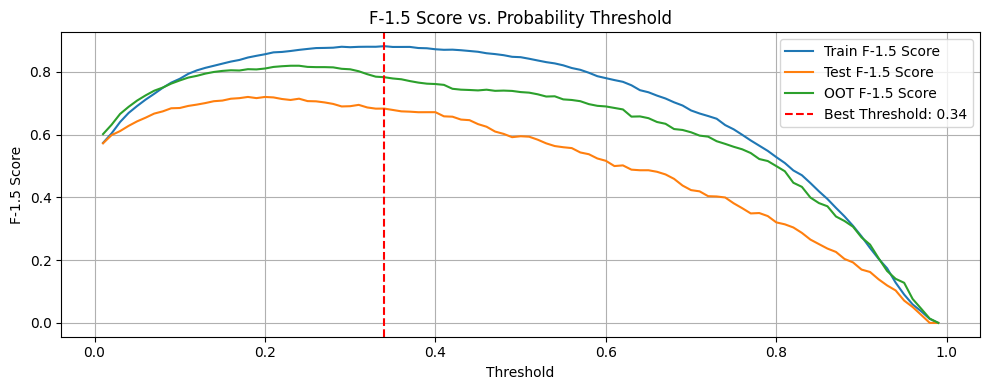

In [36]:
# Plot F1 Score vs. Threshold
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores_train, label=f"Train F-{beta} Score")
plt.plot(thresholds, f1_scores_test, label=f"Test F-{beta} Score")
plt.plot(thresholds, f1_scores_oot, label=f"OOT F-{beta} Score")
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.title(f"F-{beta} Score vs. Probability Threshold")
plt.xlabel("Threshold")
plt.ylabel(f"F-{beta} Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

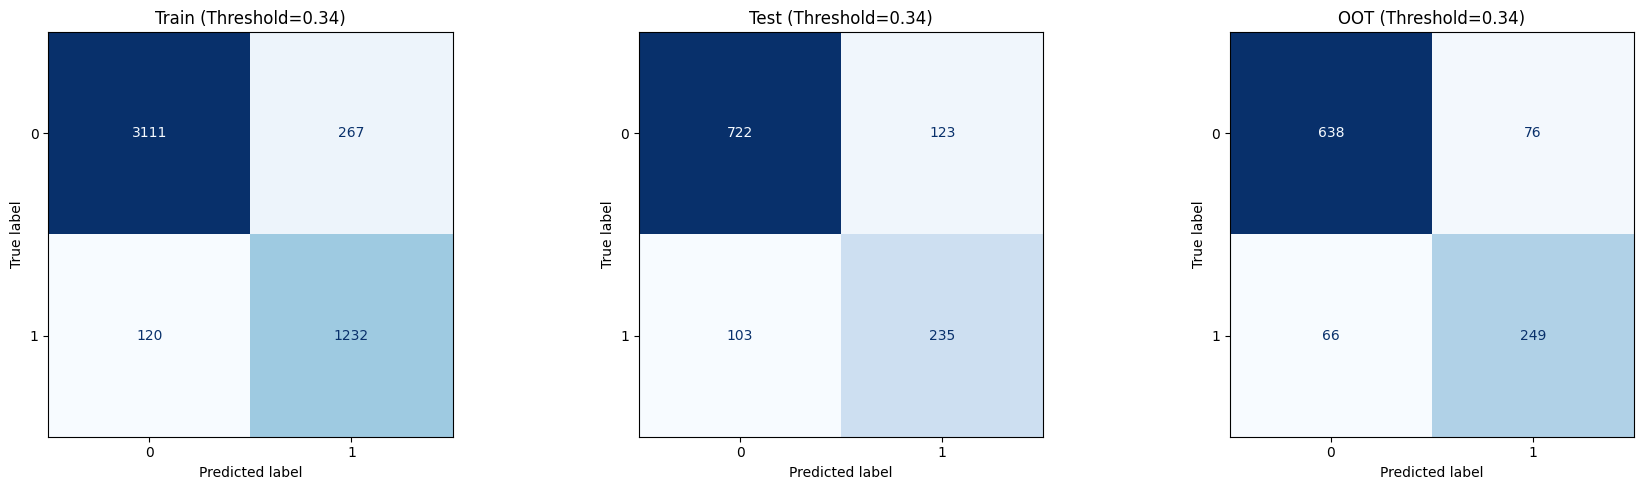

In [37]:
# Predictions
y_pred_train = (y_pred_proba_train > best_threshold).astype(int)
y_pred_test = (y_pred_proba_test > best_threshold).astype(int)
y_pred_oot = (y_pred_proba_oot > best_threshold).astype(int)

# Confusion matrices
cm_train = confusion_matrix(y_train_arr, y_pred_train)
cm_test = confusion_matrix(y_test_arr, y_pred_test)
cm_oot = confusion_matrix(y_oot_arr, y_pred_oot)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Train
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axs[0], cmap='Blues', colorbar=False)
axs[0].set_title(f"Train (Threshold={best_threshold:.2f})")
axs[0].grid(False)

# Test
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(ax=axs[1], cmap='Blues', colorbar=False)
axs[1].set_title(f"Test (Threshold={best_threshold:.2f})")
axs[1].grid(False)

# OOT
disp_oot = ConfusionMatrixDisplay(confusion_matrix=cm_oot)
disp_oot.plot(ax=axs[2], cmap='Blues', colorbar=False)
axs[2].set_title(f"OOT (Threshold={best_threshold:.2f})")
axs[2].grid(False)

plt.tight_layout()
plt.show()

In [42]:
import joblib
import os

# Save model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_dir = "model_bank"  # Directory path
model_path = f"{model_dir}/xgb_{model_train_date_str}_{timestamp}.pkl"  # File path

model_package = {
    'model': best_model,
    'scaler': scaler,
    'best_params': study.best_params,
    'performance': {
        'train_auc': train_auc,
        'test_auc': test_auc,
        'oot_auc': oot_auc,
        'best_threshold': best_threshold,
        'max_fbeta_train': max(f1_scores_train),
        'max_fbeta_test': max(f1_scores_test),
        'max_fbeta_oot': max(f1_scores_oot)
    },
    'config': config,
    'feature_columns': X_train.drop(columns=['customer_id', 'snapshot_date']).columns.tolist()
}

# Create directory if it doesn't exist
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the model file
joblib.dump(model_package, model_path)
print(f"\nXGBoost model saved to: {model_path}")


XGBoost model saved to: model_bank/xgb_2024-09-02_20250627_104258.pkl


Training Logistic Regression as a secondary model for comparison

In [46]:
# Logistic Regression hyperparameter tuning with Optuna
def objective(trial):
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    
    params = {
        'C': trial.suggest_float('C', 1e-4, 1e2, log=True),
        'penalty': penalty,
        'max_iter': trial.suggest_int('max_iter', 100, 2000),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Set solver based on penalty
    if penalty == 'l1':
        params['solver'] = 'liblinear'
    elif penalty == 'l2':
        params['solver'] = trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'sag', 'saga'])
    else:  # elasticnet
        params['solver'] = 'saga'
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)
    
    model = LogisticRegression(**params)
    model.fit(X_train_arr, y_train_arr)
    y_pred = model.predict_proba(X_test_arr)[:, 1]
    return roc_auc_score(y_test_arr, y_pred)

In [48]:
# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Train best model
best_model = LogisticRegression(**study.best_params)
best_model.fit(X_train_arr, y_train_arr)

print(f"Best parameters for Logistic Regression: {study.best_params}")
print(f"Best cross-validation AUC: {study.best_value:.4f}")

[I 2025-06-27 10:52:35,482] A new study created in memory with name: no-name-f6d63603-cece-46e6-9dd0-5bc078238abd
/usr/local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
[I 2025-06-27 10:52:35,576] Trial 0 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0006784366061112627, 'max_iter': 187}. Best is trial 0 with value: 0.5.
[I 2025-06-27 10:52:42,087] Trial 1 finished with value: 0.8284093694198382 and parameters: {'penalty': 'elasticnet', 'C': 2.9370368440260433, 'max_iter': 1958, 'l1_ratio': 0.24433987266809132}. Best is trial 1 with value: 0.8284093694198382.
[I 2025-06-27 10:52:42,419] Trial 2 finished with value: 0.7791708973775427 and parameters: {'penalty': 'l2', 'C': 0.00015617699318230574, 'max_iter': 864, 'solver': 'sag'}. Best is trial 1 with value: 0.8284093694198382.
/usr/local/lib/python3.12/site-packages/skl

Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 0.008387657660479943, 'max_iter': 122, 'solver': 'lbfgs'}
Best cross-validation AUC: 0.8301


In [49]:
# Evaluate model on all splits
y_pred_proba_train = best_model.predict_proba(X_train_arr)[:, 1]
y_pred_proba_test = best_model.predict_proba(X_test_arr)[:, 1]
y_pred_proba_oot = best_model.predict_proba(X_oot_arr)[:, 1]

# Calculate AUC scores
train_auc = roc_auc_score(y_train_arr, y_pred_proba_train)
test_auc = roc_auc_score(y_test_arr, y_pred_proba_test)
oot_auc = roc_auc_score(y_oot_arr, y_pred_proba_oot)

# Calculate F-beta scores across thresholds
thresholds = np.arange(0.01, 1.0, 0.01)
beta = 1.5

f1_scores_train = [fbeta_score(y_train_arr, (y_pred_proba_train > t).astype(int), beta=beta, zero_division=0) 
                   for t in thresholds]
f1_scores_test = [fbeta_score(y_test_arr, (y_pred_proba_test > t).astype(int), beta=beta, zero_division=0) 
                  for t in thresholds]
f1_scores_oot = [fbeta_score(y_oot_arr, (y_pred_proba_oot > t).astype(int), beta=beta, zero_division=0) 
                 for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores_train)]

# Print results
print(f"\nLogistic Regression Model Results:")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"OOT AUC: {oot_auc:.4f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Max F-beta (Train): {max(f1_scores_train):.4f}")
print(f"Max F-beta (Test): {max(f1_scores_test):.4f}")
print(f"Max F-beta (OOT): {max(f1_scores_oot):.4f}")


Logistic Regression Model Results:
Train AUC: 0.8769
Test AUC: 0.8301
OOT AUC: 0.8973
Best Threshold: 0.240
Max F-beta (Train): 0.7376
Max F-beta (Test): 0.6922
Max F-beta (OOT): 0.7620


In [ ]:
# Save model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = f"model_bank/{model_name}_{snapshot_date}_{timestamp}.pkl"

model_package = {
    'model': best_model,
    'scaler': scaler,
    'best_params': study.best_params,
    'performance': {
        'train_auc': train_auc,
        'test_auc': test_auc,
        'oot_auc': oot_auc,
        'best_threshold': best_threshold,
        'max_fbeta_train': max(f1_scores_train),
        'max_fbeta_test': max(f1_scores_test),
        'max_fbeta_oot': max(f1_scores_oot)
    },
    'config': config,
    'feature_columns': X_train.drop(columns=['customer_id', 'snapshot_date']).columns.tolist()
}

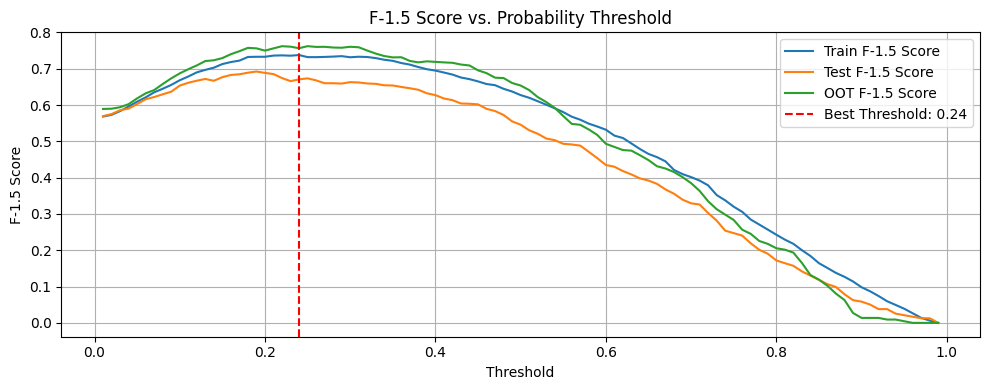

In [50]:
# Plot F1 Score vs. Threshold
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores_train, label=f"Train F-{beta} Score")
plt.plot(thresholds, f1_scores_test, label=f"Test F-{beta} Score")
plt.plot(thresholds, f1_scores_oot, label=f"OOT F-{beta} Score")
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.title(f"F-{beta} Score vs. Probability Threshold")
plt.xlabel("Threshold")
plt.ylabel(f"F-{beta} Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
# Save model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_dir = "model_bank"  # Directory path
model_path = f"{model_dir}/logreg_{model_train_date_str}_{timestamp}.pkl"  # File path

# Create directory if it doesn't exist
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the model file
joblib.dump(model_package, model_path)
print(f"\nLogistic Regression model saved to: {model_path}")


Logistic Regression model saved to: model_bank/logreg_2024-09-02_20250627_105742.pkl


In [163]:
# Train model
clf = LogisticRegression()
clf.fit(X_train_arr, y_train_arr)

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(clf, f)

**Evaluate CreditKarma Scorer**

In [164]:
# Load model
with open("model.pkl", "rb") as f:
    clf = pickle.load(f)

In [179]:
# Predict and evaluate
y_pred_proba_train = clf.predict_proba(X_train_arr)[:, 1]
train_auc = roc_auc_score(y_train_arr, y_pred_proba_train)

y_pred_proba_test = clf.predict_proba(X_test_arr)[:, 1]
test_auc = roc_auc_score(y_test_arr, y_pred_proba_test)

y_pred_proba_oot = clf.predict_proba(X_oot_arr)[:, 1]
oot_auc = roc_auc_score(y_oot_arr, y_pred_proba_oot)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"OOT AUC: {oot_auc:.4f}")

Train AUC: 0.8788
Test AUC: 0.8284
OOT AUC: 0.9046


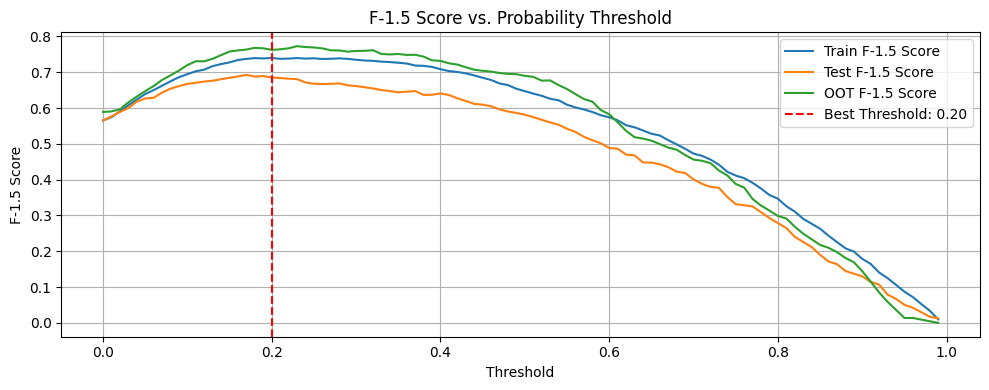

In [ ]:
# F2 score across thresholds
thresholds = np.arange(0.0, 1.0, 0.01)
beta = 1.5
f1_scores_train = [fbeta_score(y_train_arr, y_pred_proba_train > t, beta=beta) for t in thresholds]
f1_scores_test = [fbeta_score(y_test_arr, y_pred_proba_test > t, beta=beta) for t in thresholds]
f1_scores_oot = [fbeta_score(y_oot_arr, y_pred_proba_oot > t, beta=beta) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores_train)]

# Plot F1 Score vs. Threshold
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores_train, label=f"Train F-{beta} Score")
plt.plot(thresholds, f1_scores_test, label=f"Test F-{beta} Score")
plt.plot(thresholds, f1_scores_oot, label=f"OOT F-{beta} Score")
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.title(f"F-{beta} Score vs. Probability Threshold")
plt.xlabel("Threshold")
plt.ylabel(f"F-{beta} Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

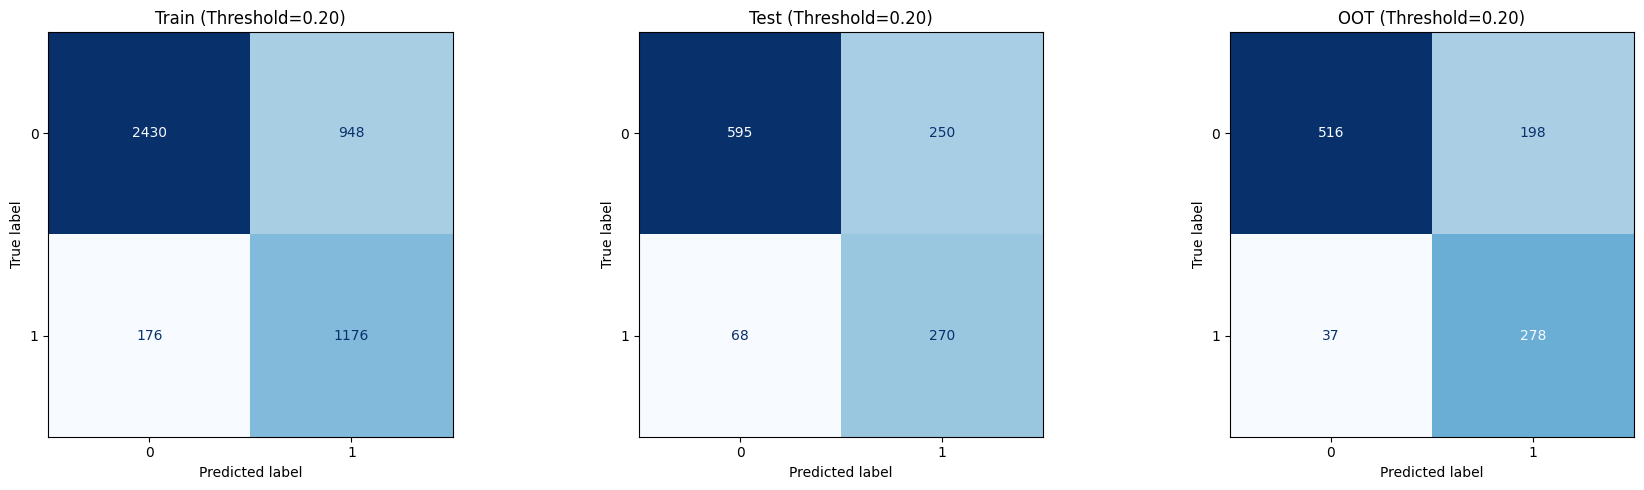

In [190]:
# Predictions
y_pred_train = (y_pred_proba_train > best_threshold).astype(int)
y_pred_test = (y_pred_proba_test > best_threshold).astype(int)
y_pred_oot = (y_pred_proba_oot > best_threshold).astype(int)

# Confusion matrices
cm_train = confusion_matrix(y_train_arr, y_pred_train)
cm_test = confusion_matrix(y_test_arr, y_pred_test)
cm_oot = confusion_matrix(y_oot_arr, y_pred_oot)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Train
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axs[0], cmap='Blues', colorbar=False)
axs[0].set_title(f"Train (Threshold={best_threshold:.2f})")
axs[0].grid(False)

# Test
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(ax=axs[1], cmap='Blues', colorbar=False)
axs[1].set_title(f"Test (Threshold={best_threshold:.2f})")
axs[1].grid(False)

# OOT
disp_oot = ConfusionMatrixDisplay(confusion_matrix=cm_oot)
disp_oot.plot(ax=axs[2], cmap='Blues', colorbar=False)
axs[2].set_title(f"OOT (Threshold={best_threshold:.2f})")
axs[2].grid(False)

plt.tight_layout()
plt.show()

In [191]:
print(f"Best Train F{beta}-Score: {max(f1_scores_train):.4f}")
print(f"Best Test F{beta}-Score: {max(f1_scores_test):.4f}")
print(f"Best OOT F{beta}-Score: {max(f1_scores_oot):.4f}")

Best Train F1.5-Score: 0.7398
Best Test F1.5-Score: 0.6927
Best OOT F1.5-Score: 0.7728
